In [208]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler , LabelEncoder , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import warnings 
warnings.filterwarnings('ignore')

In [209]:
data = pd.read_csv('diabetes_prediction_dataset.csv')
df = data.copy()
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [210]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [212]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [213]:
df.duplicated().sum()

np.int64(3854)

In [214]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [215]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [216]:
df['gender'] = df['gender'].replace('Other' , 'Male')
df['gender'].value_counts()

gender
Female    56161
Male      39985
Name: count, dtype: int64

In [217]:
df['smoking_history'].value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

<Axes: xlabel='smoking_history', ylabel='count'>

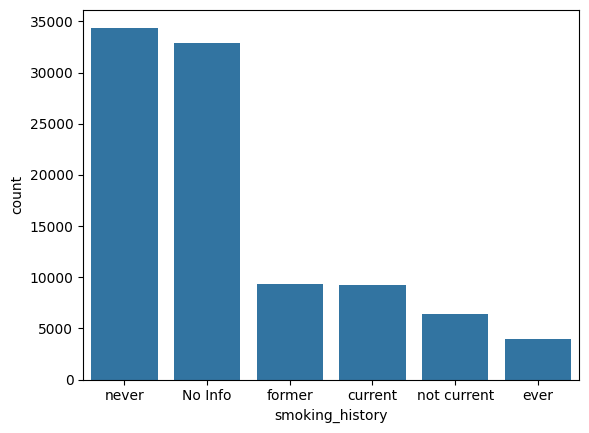

In [218]:
sns.barplot( df['smoking_history'].value_counts() )

<Axes: >

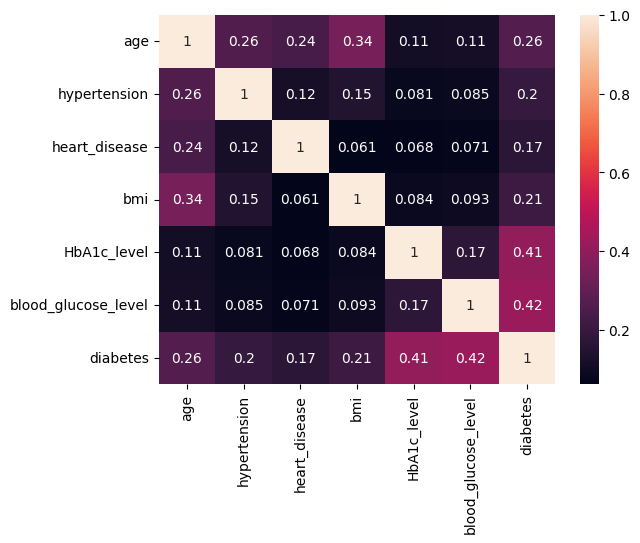

In [219]:
corr = df.corr(numeric_only= True)
sns.heatmap(corr , annot=True)

<Axes: xlabel='diabetes', ylabel='count'>

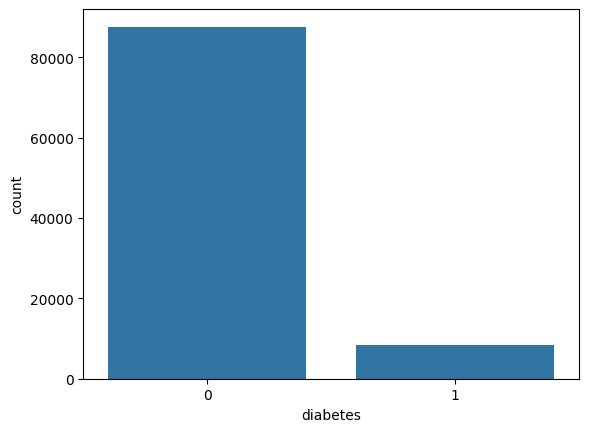

In [220]:
sns.barplot(df['diabetes'].value_counts())

In [221]:
df = pd.get_dummies(df , columns=['gender' , 'smoking_history']).astype(int)
df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80,0,1,25,6,140,0,1,0,0,0,0,0,1,0
1,54,0,0,27,6,80,0,1,0,1,0,0,0,0,0
2,28,0,0,27,5,158,0,0,1,0,0,0,0,1,0
3,36,0,0,23,5,155,0,1,0,0,1,0,0,0,0
4,76,1,1,20,4,155,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,36,0,0,24,4,145,0,1,0,1,0,0,0,0,0
99996,2,0,0,17,6,100,0,1,0,1,0,0,0,0,0
99997,66,0,0,27,5,155,0,0,1,0,0,0,1,0,0
99998,24,0,0,35,4,100,0,1,0,0,0,0,0,1,0


# Feture Selection


In [222]:
X = df.drop(columns = ['heart_disease' , 'diabetes'])
y = df['diabetes']

# Scaling The Data

In [223]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# model Training and testing 

In [224]:
X_train , X_test , y_train , y_test = train_test_split(X_scaled , y , random_state=42 , test_size= 0.2)

In [225]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [226]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(19230,))

In [227]:
y_test

2547     0
34774    0
71084    1
50584    0
80788    0
        ..
19314    0
17624    0
8673     0
37062    0
21353    0
Name: diabetes, Length: 19230, dtype: int64

In [228]:
accuracy_score(y_test , y_pred)

0.8760790431617265

# Naive Baiyes model  

In [229]:
model_nb = GaussianNB()
model_nb.fit(X_train ,y_train)


,priors,None
,var_smoothing,1e-09


In [230]:
y_pred = model_nb.predict(X_test)
accuracy_score(y_test , y_pred)

0.9058242329693188

In [231]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
models = {
    'logistic' : LogisticRegression(class_weight='balanced'),
    'naive' : GaussianNB(),
    'tree' : DecisionTreeClassifier(),
    'KNN' : KNeighborsClassifier(n_neighbors= 5),
    'svm' : SVC() }
    

In [234]:
result = []

In [ ]:
for name , model in models.items():
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test , y_pred)
    cr = classification_report(y_test , y_pred)
    result.append(
    [name , print(cr)]
    )
    print(f'model is : {name} and its acc is : {acc}')
    print(result)

              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17509
           1       0.41      0.87      0.56      1721

    accuracy                           0.88     19230
   macro avg       0.70      0.88      0.74     19230
weighted avg       0.93      0.88      0.89     19230

model is : logistic and its acc is : 0.8760790431617265
[['logistic', '              precision    recall  f1-score   support\n\n           0       0.99      0.88      0.93     17509\n           1       0.41      0.87      0.56      1721\n\n    accuracy                           0.88     19230\n   macro avg       0.70      0.88      0.74     19230\nweighted avg       0.93      0.88      0.89     19230\n'], ['naive', '              precision    recall  f1-score   support\n\n           0       0.97      0.93      0.95     17509\n           1       0.48      0.67      0.56      1721\n\n    accuracy                           0.91     19230\n   macro avg       0.72      